# Rental Crisis in Portugal: Rents vs Wages (H1) and the Spread beyond Big Cities (H3)

**H1:** Rents on new leases in Portugal have grown faster than wages since 2017.

**H3:** Since 2020, rents on new leases have grown faster (in %) in small municipalities (< 50,000 inhabitants) than in big ones (≥ 50,000): the rent crisis is spreading beyond the big cities.

**Data:** six indicators from INE (Statistics Portugal), collected via its JSON API.

| Series | INE code | Coverage | Used for |
|---|---|---|---|
| Median rent €/m², new leases, last 12 months (2021 methodology, NUTS 2013) | `0009817` | H2 2017 – H2 2023 | H1: rent 2017–2020 |
| Same indicator, NUTS 2024 geography | `0012598` | H2 2020 – H2 2024 | H1: rent 2020–2024 |
| Median rent €/m², new leases, last 12 months (2026 methodology) | `0014696` | Q1 2020 – Q2 2026 | H1: rent growth 2025 · H3: rent by municipality |
| Average gross monthly earnings per employee | `0011132` | Q1 2014 – Q2 2026 | H1: wages |
| Number of new leases, last 12 months (2026 methodology) | `0014707` | Q1 2020 – Q2 2026 | H3: weights and minimum sample size |
| Resident population, annual estimates | `0012917` | annual | H3: big vs small municipalities |

**Method:** H1 aligns all series to the same 12-month windows (ending June and December) and indexes them to H2 2017 = 100. H3 compares rent growth by municipality between the 12 months to December 2020 and the 12 months to December 2025, within one methodology.

**Notebook structure**
1. Setup
2. Data collection (INE API)
3. Inspection
4. Cleaning: rent
5. Chain-linking the 2026 methodology
6. Cleaning: wages
7. Main cleaning function
8. Analysis (H1)
9. H3: big vs small municipalities
10. Visualisation
11. Conclusion

## 1. Setup

In [1]:
import json
import time
from pathlib import Path

import pandas as pd
import requests

pd.set_option("display.max_columns", None)

# Folders
RAW_DIR = Path("data/raw")
CLEAN_DIR = Path("data/clean")
for folder in (RAW_DIR, CLEAN_DIR):
    folder.mkdir(parents=True, exist_ok=True)

# INE API
INE_URL = "https://www.ine.pt/ine/json_indicador/pindica.jsp"

INDICATORS = {
    "rent_2013": "0009817",       # median rent €/m², last 12 months, semi-annual, 2021 methodology, NUTS 2013
    "rent_2024": "0012598",       # same indicator, NUTS 2024 geography
    "rent_2026": "0014696",       # median rent €/m², last 12 months, quarterly, 2026 methodology, NUTS 2024
    "wages": "0011132",           # average gross monthly earnings per employee, quarterly
    "contracts_2026": "0014707",  # number of new leases, last 12 months, quarterly, 2026 methodology, NUTS 2024
    "population": "0012917",      # resident population, annual estimates, NUTS 2024
}

# H1: analysis period
BASE_DATE = pd.Timestamp("2017-12-31")   # H2 2017 = 100
CHAIN_DATE = pd.Timestamp("2024-12-31")  # last 2021-methodology value; 2026-methodology growth added after this
END_DATE = pd.Timestamp("2025-12-31")    # 12 months to December 2025 (data allows up to 2026-06-30)

# H3: municipalities
H3_START = pd.Timestamp("2020-12-31")    # 12 months to December 2020
BIG_CITY_THRESHOLD = 50_000              # inhabitants: big (>=) vs small (<) municipalities
MIN_CONTRACTS = 100                      # minimum new leases in the last 12 months for the top-10 ranking

# Published INE figures used to validate the cleaned data
VALIDATION = {
    "rent_h2_2017": 4.39,         # national median rent €/m², last 12 months to Dec 2017
    "rent_2024": 7.97,            # national median rent €/m², 2024
    "wage_total_q4_2025": 1877,   # average gross monthly earnings, total, quarter ended Dec 2025
    "wage_total_q1_2026": 1611,   # same, quarter ended Mar 2026
    "wage_base_q1_2026": 1335,    # base component, quarter ended Mar 2026
    "wage_total_2025": 1694,      # annual average 2025, total
}


def half_year_labels(index: pd.DatetimeIndex) -> list:
    """Readable period labels: 2017-12-31 -> 'H2 2017', 2018-06-30 -> 'H1 2018'."""
    return [f"H{1 if date.month == 6 else 2} {date.year}" for date in index]

## 2. Data collection (INE API)

- Each indicator is requested once with all periods (`Dim1="T"`) and cached as JSON in `data/raw/`. Later runs read the local file instead of calling the API again.
- INE's server can be slow: requests time out after 180 s and are retried up to 3 times, waiting longer after each failed attempt.
- The code of the 2026-methodology series (`0014696`) was found by searching Portugal's open data portal (dados.gov.pt), which harvests INE's indicators.

In [2]:
def fetch_ine(varcd: str, lang: str = "EN", use_cache: bool = True,
              retries: int = 3, timeout: int = 180) -> list:
    """Fetch all periods of one INE indicator as JSON and cache it locally."""
    cache = RAW_DIR / f"ine_{varcd}_all.json"
    if use_cache and cache.exists():
        return json.loads(cache.read_text(encoding="utf-8"))

    params = {"op": "2", "varcd": varcd, "lang": lang, "Dim1": "T"}
    for attempt in range(1, retries + 1):
        try:
            response = requests.get(INE_URL, params=params, timeout=timeout)
            response.raise_for_status()
            payload = response.json()
            break
        except (requests.Timeout, requests.ConnectionError) as err:
            if attempt == retries:
                raise
            wait = 15 * attempt
            print(f"{varcd}: attempt {attempt} failed ({type(err).__name__}), retrying in {wait}s")
            time.sleep(wait)

    cache.write_text(json.dumps(payload, ensure_ascii=False), encoding="utf-8")
    return payload


def describe_payload(payload: list) -> None:
    """Print indicator code, name, last update and period range."""
    meta = payload[0]
    periods = list(meta["Dados"].keys())
    print("Code:    ", meta["IndicadorCod"])
    print("Name:    ", meta["IndicadorDsg"])
    print("Updated: ", meta["DataUltimoAtualizacao"])
    print("Periods: ", len(periods), "|", periods[0], "→", periods[-1])
    print("-" * 90)

In [3]:
payloads = {name: fetch_ine(code) for name, code in INDICATORS.items()}

for payload in payloads.values():
    describe_payload(payload)

Code:     0009817
Name:     Median house rental value of new lease agreements of dwellings in the last 12 months (2021 Methodology - €/ m²) by Geographic location (NUTS - 2013); Semi-annual - Statistics Portugal, House rental statistics at local level
Updated:  2024-03-28
Periods:  13 | 2nd Semi-annual 2017 → 2nd Semi-annual 2023
------------------------------------------------------------------------------------------
Code:     0012598
Name:     Median house rental value of new lease agreements of dwellings in the last 12 months (2021 Methodology - €/ m²) by Geographic localization (NUTS - 2024); Semi-annual - Statistics Portugal, House rental statistics at local level
Updated:  2025-06-27
Periods:  9 | 2nd Semi-annual 2020 → 2nd Semi-annual 2024
------------------------------------------------------------------------------------------
Code:     0014696
Name:     Median house rental value of new lease agreements of dwellings in the last 12 months (2026 Methodology - €/ m²) by Geograph

## 3. Inspection

- **Rent:** one row per geographic unit per period (country, regions, municipalities). Values are medians of the **last 12 months**. Labels are semi-annual in the 2021 methodology ("2nd Semi-annual 2017") and quarterly in the 2026 methodology ("4th Quarter 2025").
- **Wages:** labels are monthly, but each value refers to the **quarter ending in that month** ("March 2026" = Q1 2026). There are 20 rows per period: earnings component (`dim_3`) × activity type (`dim_4`).
- `valor` is the numeric value stored as text; `ind_string` is the same value formatted with a decimal comma; `sinal_conv` marks unavailable or confidential values.

In [4]:
def flatten_ine(payload: list) -> pd.DataFrame:
    """Turn INE's nested {period: [records]} structure into a flat DataFrame."""
    rows = [
        {"period": period, **record}
        for period, records in payload[0]["Dados"].items()
        for record in records
    ]
    return pd.DataFrame(rows)


raw = {name: flatten_ine(payload) for name, payload in payloads.items()}

for name, df in raw.items():
    n_pt = (df["geocod"] == "PT").sum()
    print(f"{name:10} shape: {str(df.shape):12} periods: {df['period'].nunique():4}   rows for Portugal: {n_pt}")

rent_2013  shape: (8255, 7)    periods:   13   rows for Portugal: 13
rent_2024  shape: (5742, 7)    periods:    9   rows for Portugal: 9
rent_2026  shape: (16588, 7)   periods:   26   rows for Portugal: 26
wages      shape: (2960, 11)   periods:  148   rows for Portugal: 2960
contracts_2026 shape: (16588, 7)   periods:   26   rows for Portugal: 26
population shape: (36435, 9)   periods:    5   rows for Portugal: 105


In [5]:
# Wage dimensions: we need the Total component (dim_3 = T) and all activities (dim_4 = T)
raw["wages"][["dim_3", "dim_3_t", "dim_4", "dim_4_t"]].drop_duplicates().reset_index(drop=True)

,dim_3,dim_3_t,dim_4,dim_4_t
0,1,Regular,1,Tradable
1,11,Base,1,Tradable
2,12,Other regular components,1,Tradable
3,2,Non-regular,1,Tradable
4,T,Total,1,Tradable
5,1,Regular,2,Non-tradable market
6,11,Base,2,Non-tradable market
7,12,Other regular components,2,Non-tradable market
8,2,Non-regular,2,Non-tradable market
9,T,Total,2,Non-tradable market


In [6]:
# Rent, Portugal: first rows of each series
for name in ["rent_2013", "rent_2024", "rent_2026"]:
    df = raw[name]
    display(df.loc[df["geocod"] == "PT", ["period", "geocod", "geodsg", "valor", "sinal_conv"]].head(3))

,period,geocod,geodsg,valor,sinal_conv
255,2nd Semi-annual 2017,PT,Portugal,4.39,NaN
885,1st Semi-annual 2018,PT,Portugal,4.58,NaN
1519,2nd Semi-annual 2018,PT,Portugal,4.8,NaN


,period,geocod,geodsg,valor,sinal_conv
233,2nd Semi-annual 2020,PT,Portugal,5.61,NaN
878,1st Semi-annual 2021,PT,Portugal,5.82,NaN
1520,2nd Semi-annual 2021,PT,Portugal,6.04,NaN


,period,geocod,geodsg,valor,sinal_conv
173,1st Quarter 2020,PT,Portugal,5.56,NaN
811,2nd Quarter 2020,PT,Portugal,5.62,NaN
1449,3rd Quarter 2020,PT,Portugal,5.71,NaN


## 4. Cleaning: rent

1. Filter to Portugal (`geocod == "PT"`) and keep only the needed columns
2. Parse period labels into end-of-period dates (semesters and quarters)
3. Convert `valor` to numeric
4. Keep only periods ending in June and December, so all three series use the same 12-month windows
5. Check for missing values and duplicate dates
6. Combine the two 2021-methodology series (NUTS 2013 and NUTS 2024): at national level they should be identical, so the newer one extends the older one to H2 2024

In [7]:
PERIOD_END = {
    "Semi-annual": {"1st": "06-30", "2nd": "12-31"},
    "Quarter": {"1st": "03-31", "2nd": "06-30", "3rd": "09-30", "4th": "12-31"},
}


def parse_period(label: str) -> pd.Timestamp:
    """'2nd Semi-annual 2017' -> 2017-12-31; '3rd Quarter 2020' -> 2020-09-30."""
    number, kind, year = label.split()
    return pd.Timestamp(f"{year}-{PERIOD_END[kind][number]}")


def clean_rent(df: pd.DataFrame, geocod: str = "PT") -> pd.Series:
    """Median rent €/m² (last 12 months) for one area, at June and December period ends."""
    rent = df.loc[df["geocod"] == geocod, ["period", "valor"]].copy()
    if rent.empty:
        raise ValueError(f"No rows found for geocod '{geocod}'")

    rent["date"] = rent["period"].apply(parse_period)
    rent["valor"] = pd.to_numeric(rent["valor"], errors="coerce")
    rent = rent[rent["date"].dt.month.isin([6, 12])]

    if rent["date"].duplicated().any():
        raise ValueError("Duplicate dates found")
    return rent.set_index("date")["valor"].sort_index().rename("rent_m2")


def check(label: str, actual: float, expected: float, tolerance: float = 0.0) -> None:
    """Compare a cleaned value with a published INE figure."""
    status = "OK   " if abs(actual - expected) <= tolerance else "CHECK"
    print(f"[{status}] {label}: {actual:,.2f} (published: {expected:,.2f})")

In [8]:
rent_2013 = clean_rent(raw["rent_2013"])
rent_2024 = clean_rent(raw["rent_2024"])
rent_2026 = clean_rent(raw["rent_2026"])

for name, series in [("rent_2013", rent_2013), ("rent_2024", rent_2024), ("rent_2026", rent_2026)]:
    print(f"{name}: {len(series):2} values | {series.index.min().date()} → {series.index.max().date()}"
          f" | missing: {series.isna().sum()}")

print()
check("Rent H2 2017", rent_2013.loc[BASE_DATE], VALIDATION["rent_h2_2017"], tolerance=0.01)
check("Rent H2 2024", rent_2024.loc[CHAIN_DATE], VALIDATION["rent_2024"], tolerance=0.01)

rent_2013: 13 values | 2017-12-31 → 2023-12-31 | missing: 0
rent_2024:  9 values | 2020-12-31 → 2024-12-31 | missing: 0
rent_2026: 13 values | 2020-06-30 → 2026-06-30 | missing: 0

[OK   ] Rent H2 2017: 4.39 (published: 4.39)
[OK   ] Rent H2 2024: 7.97 (published: 7.97)


In [9]:
# The two 2021-methodology series overlap from H2 2020 to H2 2023: national values should match
overlap = pd.concat({"nuts_2013": rent_2013, "nuts_2024": rent_2024}, axis=1).dropna()
overlap["difference"] = (overlap["nuts_2024"] - overlap["nuts_2013"]).round(2)
display(overlap)

# Newer series takes priority where both exist; the older one fills H2 2017 – H1 2020
rent_2021 = rent_2024.combine_first(rent_2013)
print(f"Combined 2021 methodology: {len(rent_2021)} values | "
      f"{rent_2021.index.min().date()} → {rent_2021.index.max().date()}")

,nuts_2013,nuts_2024,difference
date,,,
2020-12-31,5.61,5.61,0.0
2021-06-30,5.82,5.82,0.0
2021-12-31,6.04,6.04,0.0
2022-06-30,6.25,6.25,0.0
2022-12-31,6.52,6.52,0.0
2023-06-30,6.86,6.86,0.0
2023-12-31,7.21,7.21,0.0


Combined 2021 methodology: 15 values | 2017-12-31 → 2024-12-31


## 5. Chain-linking the 2026 methodology

In 2026 INE revised its rent statistics. The new series gives different **levels** from the old one (end of 2020: 5.79 vs 5.61 €/m²), so the two cannot simply be joined end to end.

1. **Check:** index both methodologies to H2 2020 = 100 and compare their growth over the overlap (H2 2020 – H2 2024).
2. **Chain:** keep the 2021-methodology values up to H2 2024 and extend them with the **growth** of the 2026 methodology:

   `rent(t) = rent_2021(H2 2024) × rent_2026(t) / rent_2026(H2 2024)`

This way 2017–2024 stays entirely in one methodology, and the new methodology only contributes the change after H2 2024.

In [10]:
comparison = pd.concat({"2021 methodology": rent_2021, "2026 methodology": rent_2026}, axis=1)
comparison = comparison.loc["2020-12-31":CHAIN_DATE]
comparison_idx = comparison.div(comparison.iloc[0]).mul(100).round(1)
comparison_idx["difference_pp"] = (comparison_idx["2026 methodology"]
                                   - comparison_idx["2021 methodology"]).round(1)
display(comparison_idx)

growth_2021_method = comparison_idx["2021 methodology"].iloc[-1] - 100
growth_2026_method = comparison_idx["2026 methodology"].iloc[-1] - 100
print(f"Rent growth H2 2020 → H2 2024:  2021 methodology +{growth_2021_method:.1f}%  |  "
      f"2026 methodology +{growth_2026_method:.1f}%")

,2021 methodology,2026 methodology,difference_pp
date,,,
2020-12-31,100.0,100.0,0.0
2021-06-30,103.7,103.5,-0.2
2021-12-31,107.7,109.0,1.3
2022-06-30,111.4,114.0,2.6
2022-12-31,116.2,118.8,2.6
2023-06-30,122.3,124.0,1.7
2023-12-31,128.5,131.6,3.1
2024-06-30,135.5,139.2,3.7
2024-12-31,142.1,146.3,4.2


Rent growth H2 2020 → H2 2024:  2021 methodology +42.1%  |  2026 methodology +46.3%


In [11]:
def chain_series(old: pd.Series, new: pd.Series, chain_date: pd.Timestamp) -> pd.Series:
    """Extend `old` beyond chain_date using the growth of `new` (chain-linking)."""
    factor = old.loc[chain_date] / new.loc[chain_date]
    extension = new.loc[new.index > chain_date] * factor
    return pd.concat([old, extension]).round(2)


rent_chained = chain_series(rent_2021, rent_2026, CHAIN_DATE)
rent_chained.loc["2024-06-30":]

date
2024-06-30    7.60
2024-12-31    7.97
2025-06-30    8.39
2025-12-31    8.74
2026-06-30    9.18
Name: rent_m2, dtype: float64

## 6. Cleaning: wages

1. Keep all activities (`dim_4 == "T"`) and two components: **Total** (`T`, includes holiday and Christmas bonuses) and **Base** (`11`, used as a sensitivity check)
2. Parse month labels into dates and convert values to numeric
3. Keep only March, June, September and December: each is a separate, non-overlapping quarter
4. Reshape to one row per quarter with one column per component
5. Rolling mean over 4 quarters → 12-month average, kept at June and December to match the rent windows

In [12]:
WAGE_COMPONENTS = {"T": "wage_total", "11": "wage_base"}

MONTHS = {"January": 1, "February": 2, "March": 3, "April": 4, "May": 5, "June": 6,
          "July": 7, "August": 8, "September": 9, "October": 10, "November": 11, "December": 12}


def parse_month(label: str) -> pd.Timestamp:
    """'March 2026' -> 2026-03-31 (last day of the month)."""
    month, year = label.split()
    return pd.Timestamp(year=int(year), month=MONTHS[month], day=1) + pd.offsets.MonthEnd(0)


def clean_wages(df: pd.DataFrame) -> pd.DataFrame:
    """Quarterly earnings (total and base), all activities, indexed by quarter-end date."""
    wages = df[["period", "dim_3", "dim_4", "valor"]].astype({"dim_3": str, "dim_4": str})
    wages = wages[(wages["dim_4"] == "T") & (wages["dim_3"].isin(WAGE_COMPONENTS))].copy()

    wages["date"] = wages["period"].apply(parse_month)
    wages["valor"] = pd.to_numeric(wages["valor"], errors="coerce")
    wages = wages[wages["date"].dt.month.isin([3, 6, 9, 12])]

    wages = wages.pivot(index="date", columns="dim_3", values="valor").rename(columns=WAGE_COMPONENTS)
    wages.columns.name = None
    return wages[list(WAGE_COMPONENTS.values())].sort_index()


def wages_to_12m(wages_q: pd.DataFrame) -> pd.DataFrame:
    """12-month average (mean of 4 quarters), kept at June and December."""
    wages_12m = wages_q.rolling(window=4).mean()
    return wages_12m[wages_12m.index.month.isin([6, 12])].dropna()

In [13]:
wages_q = clean_wages(raw["wages"])
wages_12m = wages_to_12m(wages_q)

print(f"Quarterly: {wages_q.shape[0]} quarters | {wages_q.index.min().date()} → {wages_q.index.max().date()}"
      f" | missing: {wages_q.isna().sum().sum()}")
print(f"Largest gap between quarters: {wages_q.index.to_series().diff().dt.days.max():.0f} days")
print()
check("Wages total, Q4 2025", wages_q.loc["2025-12-31", "wage_total"], VALIDATION["wage_total_q4_2025"], tolerance=5)
check("Wages total, Q1 2026", wages_q.loc["2026-03-31", "wage_total"], VALIDATION["wage_total_q1_2026"], tolerance=5)
check("Wages base,  Q1 2026", wages_q.loc["2026-03-31", "wage_base"], VALIDATION["wage_base_q1_2026"], tolerance=5)
check("Wages total, 12 months to Dec 2025", wages_12m.loc["2025-12-31", "wage_total"],
      VALIDATION["wage_total_2025"], tolerance=10)

Quarterly: 50 quarters | 2014-03-31 → 2026-06-30 | missing: 0
Largest gap between quarters: 92 days

[CHECK] Wages total, Q4 2025: 1,883.00 (published: 1,877.00)
[OK   ] Wages total, Q1 2026: 1,616.00 (published: 1,611.00)
[OK   ] Wages base,  Q1 2026: 1,333.00 (published: 1,335.00)
[OK   ] Wages total, 12 months to Dec 2025: 1,695.00 (published: 1,694.00)


`OK` = matches the figure INE published at the time (within a small tolerance). `CHECK` = look closer.

**Result:** Q4 2025 (1,883 € vs 1,877 € published in Feb 2026) and Q1 2026 (1,616 € vs 1,611 €) are slightly higher than first published. Both differences are small (≈0.3%) and point in the same direction, consistent with INE revising the data in later releases (last update: August 2026). The cleaning is correct; the API simply returns the latest revised figures.

The 12-month average is a simple mean of four quarters, while INE's annual figure weights each quarter by its number of jobs, so a difference of a few euros is expected there.

## 7. Main cleaning function

`clean_all()` runs the whole pipeline in order, from the raw API tables to one aligned table: rent (combined and chain-linked) and 12-month wages per half-year, H2 2017 – H2 2025.

In [14]:
def clean_all(raw: dict) -> pd.DataFrame:
    """Raw INE tables -> aligned half-yearly table of rent and wages for the analysis period."""
    rent_2021 = clean_rent(raw["rent_2024"]).combine_first(clean_rent(raw["rent_2013"]))
    rent = chain_series(rent_2021, clean_rent(raw["rent_2026"]), CHAIN_DATE)
    wages = wages_to_12m(clean_wages(raw["wages"]))

    h1 = pd.concat([rent, wages], axis=1, join="inner").loc[BASE_DATE:END_DATE]
    h1["rent_source"] = ["2026 methodology (chain-linked)" if date > CHAIN_DATE else "2021 methodology"
                         for date in h1.index]
    return h1


h1 = clean_all(raw)

print(f"{len(h1)} half-years | {h1.index.min().date()} → {h1.index.max().date()} | "
      f"missing: {h1.isna().sum().sum()}")
h1

17 half-years | 2017-12-31 → 2025-12-31 | missing: 0


,rent_m2,wage_total,wage_base,rent_source
date,,,,
2017-12-31,4.39,1215.00,937.75,2021 methodology
2018-06-30,4.58,1218.25,943.25,2021 methodology
2018-12-31,4.80,1240.25,952.75,2021 methodology
2019-06-30,5.00,1257.00,964.00,2021 methodology
2019-12-31,5.32,1275.75,976.25,2021 methodology
2020-06-30,5.47,1290.50,990.25,2021 methodology
2020-12-31,5.61,1315.50,1008.75,2021 methodology
2021-06-30,5.82,1343.25,1028.25,2021 methodology
2021-12-31,6.04,1360.25,1039.00,2021 methodology


## 8. Analysis

All three series are indexed to H2 2017 = 100, so growth can be compared directly even though the units differ (€/m² vs €/month).

In [15]:
VALUE_COLUMNS = ["rent_m2", "wage_total", "wage_base"]


def add_index(df: pd.DataFrame, base_date: pd.Timestamp) -> pd.DataFrame:
    """Index every column to base_date = 100."""
    return df.div(df.loc[base_date]).mul(100).round(1).add_suffix("_idx")


h1_idx = add_index(h1[VALUE_COLUMNS], BASE_DATE)
h1_full = h1.join(h1_idx)
h1_full.to_csv(CLEAN_DIR / "h1_rent_vs_wages.csv")

growth = h1_idx.iloc[-1] - 100
gap = growth["rent_m2_idx"] - growth["wage_total_idx"]

start_label, end_label = half_year_labels(h1_idx.index[[0, -1]])
print(f"Growth {start_label} → {end_label} (12-month windows)")
print(f"  Rent, new leases (€/m²):  +{growth['rent_m2_idx']:.1f}%")
print(f"  Wages, total:             +{growth['wage_total_idx']:.1f}%")
print(f"  Wages, base:              +{growth['wage_base_idx']:.1f}%")
print(f"  Gap, rent vs total wages: {gap:.1f} percentage points")
print(f"  Rent increase = {growth['rent_m2_idx'] / growth['wage_total_idx']:.1f}x the total wage increase")

h1_full

Growth H2 2017 → H2 2025 (12-month windows)
  Rent, new leases (€/m²):  +99.1%
  Wages, total:             +39.5%
  Wages, base:              +36.1%
  Gap, rent vs total wages: 59.6 percentage points
  Rent increase = 2.5x the total wage increase


,rent_m2,wage_total,wage_base,rent_source,rent_m2_idx,wage_total_idx,wage_base_idx
date,,,,,,,
2017-12-31,4.39,1215.00,937.75,2021 methodology,100.0,100.0,100.0
2018-06-30,4.58,1218.25,943.25,2021 methodology,104.3,100.3,100.6
2018-12-31,4.80,1240.25,952.75,2021 methodology,109.3,102.1,101.6
2019-06-30,5.00,1257.00,964.00,2021 methodology,113.9,103.5,102.8
2019-12-31,5.32,1275.75,976.25,2021 methodology,121.2,105.0,104.1
2020-06-30,5.47,1290.50,990.25,2021 methodology,124.6,106.2,105.6
2020-12-31,5.61,1315.50,1008.75,2021 methodology,127.8,108.3,107.6
2021-06-30,5.82,1343.25,1028.25,2021 methodology,132.6,110.6,109.7
2021-12-31,6.04,1360.25,1039.00,2021 methodology,137.6,112.0,110.8


## 9. H3: big vs small municipalities

**Question:** is the rent crisis spreading beyond the big cities?

**Method**
- Rent: INE's 2026-methodology series (`0014696`), median rent €/m² of new leases in the last 12 months, per municipality. Start (12 months to Dec 2020) and end (12 months to Dec 2025) come from the **same methodology**, so no chain-linking is needed.
- Growth per municipality: `rent_growth_pct = (rent_end / rent_start − 1) × 100`
- Groups: **big** = at least 50,000 inhabitants, **small** = fewer, using INE's latest annual population estimate (`0012917`).
- Group result: the **median** growth across municipalities (each municipality counts once), plus a **lease-weighted average** (municipalities with more new leases count more, `0014707`).
- Municipalities are identified by their 7-character code (3-character NUTS III region + 4-digit municipality code); regions and parishes are excluded.

**Caveats**
- INE does not publish rents for municipalities with very few leases. Those municipalities drop out, and they are mostly small ones, so the number of municipalities per group is reported.
- The national figure is the median over *all* new leases in Portugal, not an average of municipalities. Because leases are concentrated in some areas and that mix shifts over time, national growth can differ from both group figures.

In [16]:
def is_municipality(geocod: pd.Series) -> pd.Series:
    """Municipality codes have 7 characters: 3-character NUTS III region + 4-digit municipality code."""
    return geocod.astype(str).str.len() == 7


def municipal_values(df: pd.DataFrame, dates: list) -> pd.DataFrame:
    """One row per municipality (geocod), one column per requested period-end date."""
    data = df.loc[is_municipality(df["geocod"]), ["geocod", "period", "valor"]].copy()
    data["date"] = data["period"].apply(parse_period)
    data["valor"] = pd.to_numeric(data["valor"], errors="coerce")
    data = data[data["date"].isin(dates)]
    if data.duplicated(subset=["geocod", "date"]).any():
        raise ValueError("Duplicate municipality/period rows found")
    return data.pivot(index="geocod", columns="date", values="valor")


def clean_population(df: pd.DataFrame) -> tuple:
    """Total resident population per municipality (all sexes, all ages) for the latest year with data."""
    dim_codes = [col for col in df.columns if col.startswith("dim_") and not col.endswith("_t")]
    totals = df[(df[dim_codes].astype(str) == "T").all(axis=1) & is_municipality(df["geocod"])].copy()
    if totals.empty:
        raise ValueError(f"No 'Total' rows found. Dimensions:\n{df[dim_codes].drop_duplicates()}")

    totals["year"] = totals["period"].astype(str).str.extract(r"(\d{4})")[0].astype(int)
    totals["population"] = pd.to_numeric(totals["valor"], errors="coerce")
    latest_year = totals.dropna(subset=["population"])["year"].max()
    population = totals.loc[totals["year"] == latest_year].set_index("geocod")["population"]
    return population, latest_year


def size_group(population: float) -> str:
    """'Big' / 'Small' label from the population threshold; missing population stays missing."""
    if pd.isna(population):
        return pd.NA
    return f"Big (≥ {BIG_CITY_THRESHOLD:,})" if population >= BIG_CITY_THRESHOLD else f"Small (< {BIG_CITY_THRESHOLD:,})"


def build_h3_table(raw: dict) -> tuple:
    """One row per municipality: name, rent at start and end, growth, new leases, population, size group."""
    rent_df = raw["rent_2026"]
    names = (rent_df.loc[is_municipality(rent_df["geocod"]), ["geocod", "geodsg"]]
             .drop_duplicates("geocod", keep="last").set_index("geocod")["geodsg"])

    rent = municipal_values(rent_df, [H3_START, END_DATE])
    contracts = municipal_values(raw["contracts_2026"], [END_DATE])[END_DATE]
    population, population_year = clean_population(raw["population"])

    table = (
        names.to_frame("municipality")
        .join(rent.rename(columns={H3_START: "rent_start", END_DATE: "rent_end"}))
        .join(contracts.rename("leases_end"))
        .join(population.rename("population"))
    )
    table["rent_growth_pct"] = (table["rent_end"] / table["rent_start"] - 1) * 100
    table["size_group"] = table["population"].map(size_group)
    return table, population_year


h3, population_year = build_h3_table(raw)
print(f"Population year used for the 50k split: {population_year}")
h3.head()

Population year used for the 50k split: 2025


,municipality,rent_start,rent_end,leases_end,population,rent_growth_pct,size_group
geocod,,,,,,,
11A1315,Valongo,5.32,8.04,948.0,98930,51.127820,"Big (≥ 50,000)"
11A1316,Vila do Conde,5.01,8.04,771.0,86245,60.479042,"Big (≥ 50,000)"
11A1317,Vila Nova de Gaia,6.51,10.63,4445.0,323202,63.287250,"Big (≥ 50,000)"
11A1318,Trofa,4.19,7.05,396.0,41512,68.257757,"Small (< 50,000)"
11A1304,Gondomar,5.42,8.57,1472.0,170597,58.118081,"Big (≥ 50,000)"


In [17]:
# Checks
population_raw = raw["population"]
dim_codes = [col for col in population_raw.columns if col.startswith("dim_") and not col.endswith("_t")]
pt_row = population_raw[(population_raw["geocod"] == "PT")
                        & (population_raw[dim_codes].astype(str) == "T").all(axis=1)
                        & (population_raw["period"].astype(str).str.contains(str(population_year)))]
pt_population = pd.to_numeric(pt_row["valor"], errors="coerce").iloc[0] if not pt_row.empty else float("nan")

print(f"Municipalities in the rent data:         {len(h3)} (Portugal has 308)")
print(f"  with population:                       {h3['population'].notna().sum()}")
print(f"  with rent at start and end:            {h3['rent_growth_pct'].notna().sum()}")
print(f"Sum of municipal population:             {h3['population'].sum():,.0f}")
print(f"National population ({population_year}):            {pt_population:,.0f}")
print()

coverage = h3.groupby("size_group").agg(
    municipalities=("municipality", "size"),
    with_growth=("rent_growth_pct", "count"),
)
coverage["dropped"] = coverage["municipalities"] - coverage["with_growth"]
coverage

Municipalities in the rent data:         308 (Portugal has 308)
  with population:                       308
  with rent at start and end:            221
Sum of municipal population:             11,424,031
National population (2025):            11,424,031



,municipalities,with_growth,dropped
size_group,,,
"Big (≥ 50,000)",64,64,0
"Small (< 50,000)",244,157,87


In [18]:
def summarise_groups(table: pd.DataFrame) -> pd.DataFrame:
    """Median and lease-weighted growth per size group (municipalities with growth data only)."""
    valid = table.dropna(subset=["rent_growth_pct", "size_group"])
    rows = {}
    for group, data in valid.groupby("size_group"):
        weighted = data.dropna(subset=["leases_end"])
        rows[group] = {
            "municipalities": len(data),
            "median_growth_pct": data["rent_growth_pct"].median(),
            "q25_growth_pct": data["rent_growth_pct"].quantile(0.25),
            "q75_growth_pct": data["rent_growth_pct"].quantile(0.75),
            "weighted_growth_pct": (weighted["rent_growth_pct"] * weighted["leases_end"]).sum()
                                   / weighted["leases_end"].sum(),
            "new_leases_end": data["leases_end"].sum(),
        }
    return pd.DataFrame(rows).T.astype({"municipalities": int}).round(1)


h3_summary = summarise_groups(h3)
h3.to_csv(CLEAN_DIR / "h3_municipal_rent_growth.csv")

growth_pt_h3 = (rent_2026.loc[END_DATE] / rent_2026.loc[H3_START] - 1) * 100
print(f"Rent growth, 12 months to Dec 2020 → 12 months to Dec 2025 (2026 methodology)")
print(f"  Portugal as a whole: {growth_pt_h3:+.1f}%")
for name in ["Lisboa", "Porto"]:
    row = h3.loc[h3["municipality"] == name, "rent_growth_pct"]
    if not row.empty:
        print(f"  {name}: {row.iloc[0]:+.1f}%")
h3_summary

Rent growth, 12 months to Dec 2020 → 12 months to Dec 2025 (2026 methodology)
  Portugal as a whole: +60.4%
  Lisboa: +46.3%
  Porto: +57.5%


,municipalities,median_growth_pct,q25_growth_pct,q75_growth_pct,weighted_growth_pct,new_leases_end
"Big (≥ 50,000)",64,60.3,55.9,67.9,57.7,116097.0
"Small (< 50,000)",157,57.4,43.9,69.6,60.9,31006.0


In [19]:
# Top 10 municipalities by rent growth (only municipalities with enough new leases)
top10 = (
    h3[h3["leases_end"] >= MIN_CONTRACTS]
    .nlargest(10, "rent_growth_pct")
    [["municipality", "size_group", "population", "leases_end", "rent_start", "rent_end", "rent_growth_pct"]]
)
print(f"Municipalities with at least {MIN_CONTRACTS} new leases in the 12 months to Dec 2025: "
      f"{(h3['leases_end'] >= MIN_CONTRACTS).sum()}")
top10.round(2)

Municipalities with at least 100 new leases in the 12 months to Dec 2025: 162


,municipality,size_group,population,leases_end,rent_start,rent_end,rent_growth_pct
geocod,,,,,,,
1C11513,Sines,"Small (< 50,000)",16943,130.0,5.63,12.95,130.02
1C11505,Grândola,"Small (< 50,000)",15319,127.0,4.84,10.81,123.35
1920609,Miranda do Corvo,"Small (< 50,000)",12308,129.0,3.01,6.25,107.64
1C11509,Santiago do Cacém,"Small (< 50,000)",30226,246.0,4.46,9.01,102.02
1931004,Batalha,"Small (< 50,000)",17040,179.0,3.28,6.36,93.90
1D11012,Óbidos,"Small (< 50,000)",13912,146.0,4.07,7.88,93.61
1D11005,Bombarral,"Small (< 50,000)",14366,195.0,3.40,6.50,91.18
3003108,Santa Cruz,"Small (< 50,000)",44132,279.0,5.52,10.49,90.04
3003103,Funchal,"Big (≥ 50,000)",113443,1133.0,7.03,13.20,87.77


## 10. Visualisation

In [20]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

COLORS = {
    "rent_pt": "#C0392B",   # red: rent, Portugal
    "wage": "#2E86C1",      # blue: wages
    "big": "#2C3E50",       # dark blue-grey: big municipalities
    "small": "#E67E22",     # orange: small municipalities
    "muted": "#7F8C8D",     # grey: annotations
}
SOURCE = "Source: INE (Statistics Portugal), JSON API. Rents: median €/m² of new leases, last 12 months."

plt.rcParams.update({
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#B0B0B0",
    "axes.grid": True,
    "axes.grid.axis": "y",
    "axes.axisbelow": True,
    "grid.color": "#DDDDDD",
    "xtick.color": "#555555",
    "ytick.color": "#555555",
    "xtick.major.size": 0,
    "ytick.major.size": 0,
})


def titles(ax, title: str, subtitle: str) -> None:
    """Left-aligned bold title with a grey subtitle underneath."""
    ax.set_title(title, loc="left", fontsize=15, fontweight="bold", pad=30)
    ax.text(0, 1.035, subtitle, transform=ax.transAxes, fontsize=10.5, color=COLORS["muted"])


def finish(fig, name: str) -> None:
    """Add the source note, save to figures/ and show."""
    fig.text(0.01, 0.005, SOURCE, fontsize=8, color=COLORS["muted"])
    fig.tight_layout(rect=(0, 0.03, 1, 1))
    fig.savefig(FIG_DIR / name, dpi=200, bbox_inches="tight")
    plt.show()


def group_color(group) -> str:
    """Colour for a size group label."""
    if pd.isna(group):
        return COLORS["muted"]
    return COLORS["big"] if str(group).startswith("Big") else COLORS["small"]

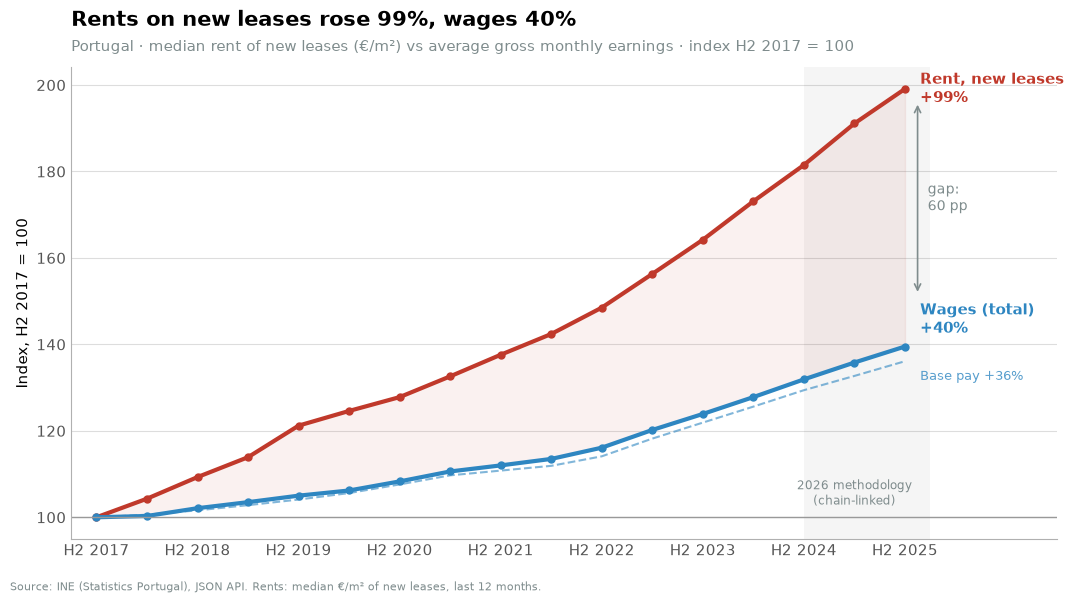

In [21]:
# Chart 1 — H1: rents vs wages, Portugal
growth_rent = h1_idx["rent_m2_idx"].iloc[-1] - 100
growth_wage = h1_idx["wage_total_idx"].iloc[-1] - 100
growth_base = h1_idx["wage_base_idx"].iloc[-1] - 100

fig, ax = plt.subplots(figsize=(11, 6))
x = list(range(len(h1_idx)))
labels = half_year_labels(h1_idx.index)
ax.set_xticks(x[::2], labels[::2])
chain_pos = h1_idx.index.get_loc(CHAIN_DATE)

# Gap between rent and wages
ax.fill_between(x, h1_idx["wage_total_idx"], h1_idx["rent_m2_idx"], color=COLORS["rent_pt"], alpha=0.07)

ax.plot(x, h1_idx["rent_m2_idx"], color=COLORS["rent_pt"], linewidth=3, marker="o", markersize=5)
ax.plot(x, h1_idx["wage_total_idx"], color=COLORS["wage"], linewidth=3, marker="o", markersize=5)
ax.plot(x, h1_idx["wage_base_idx"], color=COLORS["wage"], linewidth=1.5, linestyle="--", alpha=0.6)
ax.axhline(100, color="#999999", linewidth=1)

# Direct labels at the line ends (instead of a legend)
end = x[-1] + 0.3
ax.text(end, h1_idx["rent_m2_idx"].iloc[-1], f"Rent, new leases\n+{growth_rent:.0f}%",
        color=COLORS["rent_pt"], fontweight="bold", va="center")
ax.text(end, h1_idx["wage_total_idx"].iloc[-1] + 2, f"Wages (total)\n+{growth_wage:.0f}%",
        color=COLORS["wage"], fontweight="bold", va="bottom")
ax.text(end, h1_idx["wage_base_idx"].iloc[-1] - 2, f"Base pay +{growth_base:.0f}%",
        color=COLORS["wage"], alpha=0.8, va="top", fontsize=9.5)

# Gap bracket at the last period
low, high = h1_idx["wage_total_idx"].iloc[-1], h1_idx["rent_m2_idx"].iloc[-1]
ax.annotate("", xy=(x[-1] + 0.25, high - 3), xytext=(x[-1] + 0.25, low + 12),
            arrowprops=dict(arrowstyle="<->", color=COLORS["muted"], linewidth=1.2))
ax.text(x[-1] + 0.45, (low + 12 + high - 3) / 2, f"gap:\n{growth_rent - growth_wage:.0f} pp",
        color=COLORS["muted"], va="center", fontsize=10)

# Chain-linked period
ax.axvspan(chain_pos, x[-1] + 0.5, color="#000000", alpha=0.04, linewidth=0)
ax.text((chain_pos + x[-1]) / 2, 102, "2026 methodology\n(chain-linked)", ha="center", va="bottom",
        fontsize=8.5, color=COLORS["muted"])

ax.set_xlim(-0.5, x[-1] + 3)
ax.set_ylabel("Index, H2 2017 = 100")
titles(ax, f"Rents on new leases rose {growth_rent:.0f}%, wages {growth_wage:.0f}%",
       "Portugal · median rent of new leases (€/m²) vs average gross monthly earnings · index H2 2017 = 100")
finish(fig, "chart1_h1_rent_vs_wages.png")

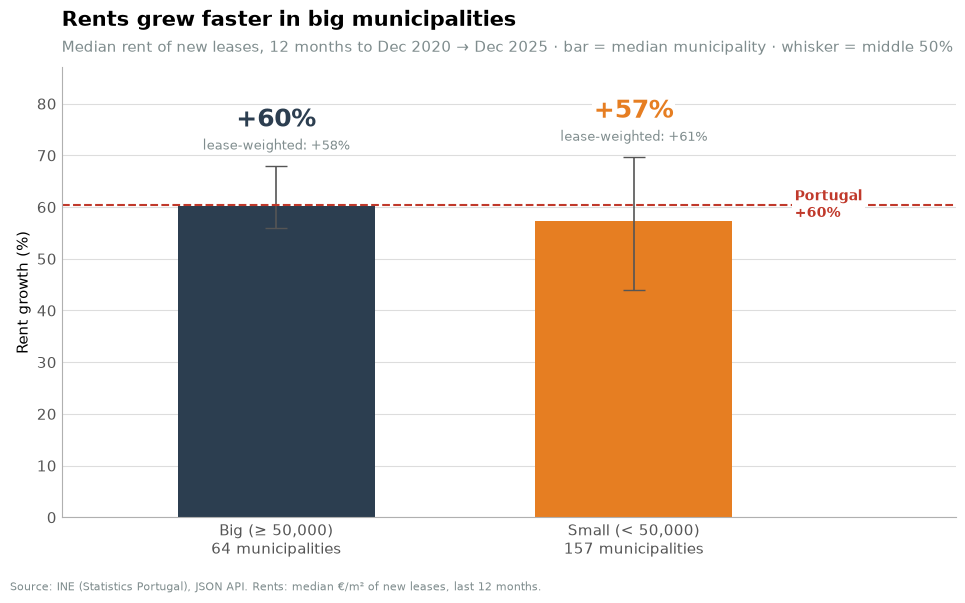

In [22]:
# Chart 2 — H3: rent growth in big vs small municipalities
summary = h3_summary.sort_index()  # "Big (...)" before "Small (...)"
x = list(range(len(summary)))
medians = summary["median_growth_pct"]

fig, ax = plt.subplots(figsize=(10.5, 6))
ax.bar(x, medians, width=0.55, color=[group_color(group) for group in summary.index])
ax.errorbar(x, medians,
            yerr=[medians - summary["q25_growth_pct"], summary["q75_growth_pct"] - medians],
            fmt="none", ecolor="#555555", elinewidth=1.2, capsize=8)

y_min = min(0, summary["q25_growth_pct"].min() * 1.2)
y_max = max(summary["q75_growth_pct"].max(), growth_pt_h3) * 1.25
ax.set_ylim(y_min, y_max)
step = (y_max - y_min) * 0.03

for pos, (group, row) in zip(x, summary.iterrows()):
    label_box = dict(facecolor="white", edgecolor="none", pad=1)
    ax.text(pos, row["q75_growth_pct"] + step, f"lease-weighted: {row['weighted_growth_pct']:+.0f}%",
            ha="center", va="bottom", fontsize=9.5, color=COLORS["muted"], bbox=label_box)
    ax.text(pos, row["q75_growth_pct"] + 2.5 * step, f"{row['median_growth_pct']:+.0f}%",
            ha="center", va="bottom", fontsize=18, fontweight="bold", color=group_color(group), bbox=label_box)

ax.axhline(growth_pt_h3, color=COLORS["rent_pt"], linestyle="--", linewidth=1.5)
ax.text(x[-1] + 0.45, growth_pt_h3, f"Portugal\n{growth_pt_h3:+.0f}%", color=COLORS["rent_pt"],
        va="center", fontweight="bold", fontsize=10, bbox=dict(facecolor="white", edgecolor="none", pad=2))

ax.set_xticks(x, [f"{group}\n{int(row['municipalities'])} municipalities" for group, row in summary.iterrows()])
ax.set_xlim(-0.6, x[-1] + 0.9)
ax.set_ylabel("Rent growth (%)")

faster = summary["median_growth_pct"].idxmax().split(" (")[0].lower()
titles(ax, f"Rents grew faster in {faster} municipalities",
       "Median rent of new leases, 12 months to Dec 2020 → Dec 2025 · "
       "bar = median municipality · whisker = middle 50%")
finish(fig, "chart2_h3_big_vs_small.png")

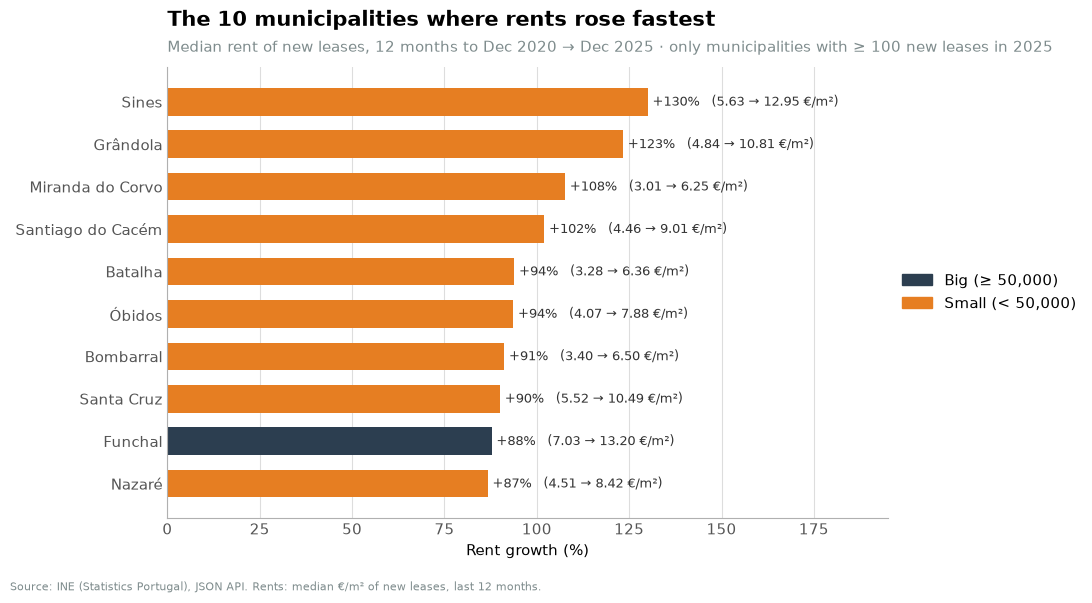

In [23]:
# Chart 3 — H3: the 10 municipalities with the fastest rent growth
top = top10.sort_values("rent_growth_pct")
y = list(range(len(top)))

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(y, top["rent_growth_pct"], color=[group_color(group) for group in top["size_group"]], height=0.65)
ax.set_yticks(y, top["municipality"])

for bar, (_, row) in zip(bars, top.iterrows()):
    ax.text(bar.get_width() + top["rent_growth_pct"].max() * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{row['rent_growth_pct']:+.0f}%   ({row['rent_start']:.2f} → {row['rent_end']:.2f} €/m²)",
            va="center", fontsize=9.5, color="#333333")

ax.set_xlim(0, top["rent_growth_pct"].max() * 1.5)
ax.grid(axis="x")
ax.grid(axis="y", visible=False)
ax.set_xlabel("Rent growth (%)")
ax.legend(handles=[Patch(color=COLORS["big"], label=f"Big (≥ {BIG_CITY_THRESHOLD:,})"),
                   Patch(color=COLORS["small"], label=f"Small (< {BIG_CITY_THRESHOLD:,})")],
          frameon=False, loc="center left", bbox_to_anchor=(1.0, 0.5))

titles(ax, "The 10 municipalities where rents rose fastest",
       f"Median rent of new leases, 12 months to Dec 2020 → Dec 2025 · "
       f"only municipalities with ≥ {MIN_CONTRACTS} new leases in 2025")
finish(fig, "chart3_h3_top10_municipalities.png")

## 11. Conclusion

### H1: rents vs wages

**H1 is supported.** Between H2 2017 and H2 2025, the median rent of new leases in Portugal rose by **99.1%** (4.39 → 8.74 €/m²), while average gross monthly earnings rose by **39.5%** (base pay: **36.1%**). Rents outpaced wages by **59.6 percentage points**; the rent increase was **2.5×** the wage increase.

**Robustness:** the result does not depend on chain-linking. Up to H2 2024, using the 2021 methodology only, rents rose **81.5%** vs wages **31.9%**.

**Method note:** 2017–2024 uses INE's 2021 rent methodology throughout. 2025 is extended with the growth of INE's 2026 methodology (chain-linked at H2 2024). Over the overlap H2 2020 – H2 2024, rents grew **42.1%** in the 2021 methodology and **46.3%** in the 2026 methodology; the new methodology shows slightly faster growth, so using the old one for 2017–2024 is the conservative choice.

### H3: big vs small municipalities

*Fill in the values from section 9.*

**H3 is [supported / not supported].** Between the 12 months to December 2020 and the 12 months to December 2025, the median small municipality (< 50,000 inhabitants) saw rents on new leases rise by **XX%**, compared with **XX%** for the median big municipality (≥ 50,000). Weighted by the number of new leases, growth was **XX%** (small) and **XX%** (big). Nationally, rents rose **XX%**; Lisbon **XX%**, Porto **XX%**.

### Limitations
- Rent is the *median of new leases per m²*; wages are the *mean across all jobs*. H1 describes pressure on people signing a new lease, not on all tenants.
- Both H1 series are nominal. Inflation affects both, so the relative comparison still holds.
- H1: 2025 rent values depend on chain-linking two methodologies.
- H3: INE does not publish rents for municipalities with very few leases; these drop out and are mostly small. Growth in small municipalities is based on fewer leases and is therefore noisier.
- H3 shows *where* rents grew faster, not *why*: it does not show that people priced out of the cities are moving further out.
- Rent data covers only leases declared to the tax authority; informal rentals are not included.

### Next steps
- H3: track where people move (internal migration data) to test the "priced out" explanation.
- Compare rents with local incomes (INE's local income statistics based on tax data).
- Adjust the H1 series for inflation.